In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
# Read training dataset and separate its features and outcome
def load_training_data(file_name, target):
    data = pd.read_csv(f"../Train and test/{file_name}")
    X = data.drop(columns=[target])
    y = data[target]
    return X, y

In [3]:
# Face-mask training datasets
X_low_face_mask, y_low_face_mask = load_training_data(
    "low_face_mask_train.csv", "face_mask_behaviour_binary"
)
X_medium_face_mask, y_medium_face_mask = load_training_data(
    "medium_face_mask_train.csv", "face_mask_behaviour_binary"
)
X_high_face_mask, y_high_face_mask = load_training_data(
    "high_face_mask_train.csv", "face_mask_behaviour_binary"
)

In [4]:
# Protective-behaviour training datasets
X_low_protective, y_low_protective = load_training_data(
    "low_protective_train.csv", "protective_behaviour_binary"
)
X_medium_protective, y_medium_protective = load_training_data(
    "medium_protective_train.csv", "protective_behaviour_binary"
)
X_high_protective, y_high_protective = load_training_data(
    "high_protective_train.csv", "protective_behaviour_binary"
)

In [5]:
# Check class balance
class_balance = pd.DataFrame({
    "Low - face mask": y_low_face_mask.value_counts(normalize=True).sort_index(),
    "Medium - face mask": y_medium_face_mask.value_counts(normalize=True).sort_index(),
    "High - face mask": y_high_face_mask.value_counts(normalize=True).sort_index(),
    "Low - protective": y_low_protective.value_counts(normalize=True).sort_index(),
    "Medium - protective": y_medium_protective.value_counts(normalize=True).sort_index(),
    "High - protective": y_high_protective.value_counts(normalize=True).sort_index(),
}).T * 100

class_balance.columns = ["Class 0 (%)", "Class 1 (%)"]
class_balance.round(2)

,Class 0 (%),Class 1 (%)
Low - face mask,29.43,70.57
Medium - face mask,47.89,52.11
High - face mask,48.36,51.64
Low - protective,28.79,71.21
Medium - protective,36.86,63.14
High - protective,33.89,66.11


In [6]:
# Find number of trees
training_tasks = [
    ("Low - face mask", X_low_face_mask, y_low_face_mask),
    ("Medium - face mask", X_medium_face_mask, y_medium_face_mask),
    ("High - face mask", X_high_face_mask, y_high_face_mask),
    ("Low - protective", X_low_protective, y_low_protective),
    ("Medium - protective", X_medium_protective, y_medium_protective),
    ("High - protective", X_high_protective, y_high_protective),
]

rf_n_estimators_values = [100, 250, 500, 750, 1000]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3034)

rf_stability_results = []

for task_name, X_train, y_train in training_tasks:
    for n_estimators in rf_n_estimators_values:
        rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=3034,
            n_jobs=-1
        )

        start_time = time.perf_counter()
        auc_scores = cross_val_score(
            rf_model,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        rf_stability_results.append({
            "task": task_name,
            "n_estimators": n_estimators,
            "mean_auc": auc_scores.mean(),
            "time_seconds": time.perf_counter() - start_time
        })

rf_stability_results = pd.DataFrame(rf_stability_results)

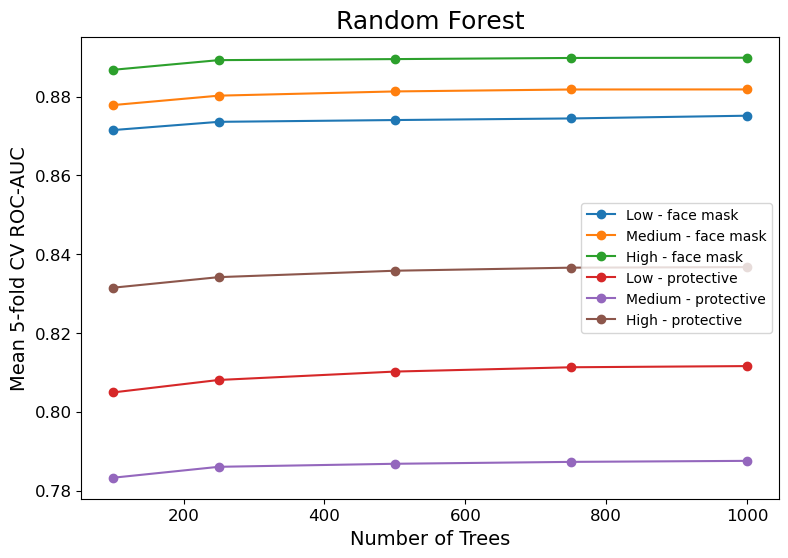

In [7]:
# Compare the AUC curves
fig, ax = plt.subplots(figsize=(9, 6))

for task_name in rf_stability_results["task"].unique():
    plot_data = rf_stability_results[
        rf_stability_results["task"] == task_name
    ]
    ax.plot(
        plot_data["n_estimators"],
        plot_data["mean_auc"],
        marker="o",
        label=task_name
    )

ax.set_xlabel("Number of Trees", fontsize=14)
ax.set_ylabel("Mean 5-fold CV ROC-AUC", fontsize=14)
ax.set_title("Random Forest", fontsize=18)
ax.tick_params(axis="both", labelsize=12)
ax.legend()
fig.savefig("../Figure/random_forest_tree_selection_auc.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Find number of XGBoost trees
# learning_rate is fixed
xgb_n_estimators_values = [100, 250, 500, 750, 1000]

xgb_stability_results = []

for task_name, X_train, y_train in training_tasks:
    for n_estimators in xgb_n_estimators_values:
        xgb_model = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=0.005,
            random_state=3034,
            eval_metric="logloss",
            n_jobs=-1
        )

        start_time = time.perf_counter()
        auc_scores = cross_val_score(
            xgb_model,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        xgb_stability_results.append({
            "task": task_name,
            "n_estimators": n_estimators,
            "mean_auc": auc_scores.mean(),
            "time_seconds": time.perf_counter() - start_time
        })

xgb_stability_results = pd.DataFrame(xgb_stability_results)

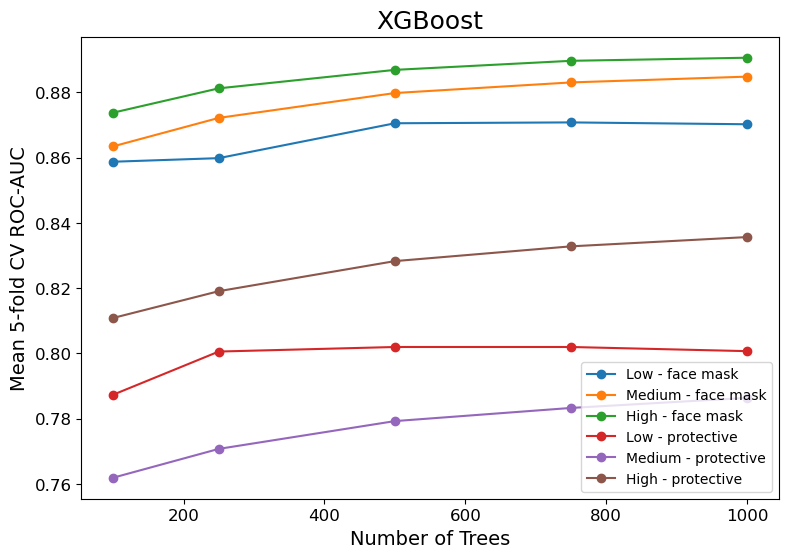

In [9]:
# Compare the XGBoost AUC curves
fig, ax = plt.subplots(figsize=(9, 6))

for task_name in xgb_stability_results["task"].unique():
    plot_data = xgb_stability_results[
        xgb_stability_results["task"] == task_name
    ]
    ax.plot(
        plot_data["n_estimators"],
        plot_data["mean_auc"],
        marker="o",
        label=task_name
    )

ax.set_xlabel("Number of Trees", fontsize=14)
ax.set_ylabel("Mean 5-fold CV ROC-AUC", fontsize=14)
ax.set_title("XGBoost", fontsize=18)
ax.tick_params(axis="both", labelsize=12)
ax.legend()
fig.savefig("../Figure/xgboost_tree_selection_auc.png", dpi=300, bbox_inches="tight")
plt.show()